In [1]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
import prettytable as pt
from matplotlib import pyplot as plt
import os 
import warnings
warnings.filterwarnings("ignore")

###################################################################################################
                                                                                                  #
from rhoova.Client import *                                                                       #   
#Register and get api key from https://app.rhoova.com/ for ClientConfig("api key", "api secret")  #
config = ClientConfig("", "")                                                                     #
api = Api(config)                                                                                 # 
                                                                                                  #
###################################################################################################

directory = os.path.normpath(os.getcwd() + os.sep + os.pardir)
datadirectory=directory+"/data/yielddata/yielddata.csv"

yielddata = pd.read_csv(datadirectory)
yielddata = yielddata.replace(np.nan, '', regex=True) 


In [2]:
# Fix parameters for building yield curve instruments
instrumentsconfig={
            "DEPO": {
                "businessDayConvention": "ModifiedFollowing",
                "dayCounter": "Actual360"
            },
            "FUTURES": {
                "businessDayConvention": "ModifiedFollowing",
                "dayCounter": "Actual360",
                "market": "IMM",
                "usedates": False
            },
            "IRS": {
                "businessDayConvention": "ModifiedFollowing",
                "dayCounter": "Actual360",
                "frequency": "Annual"
            }
        } 

In [3]:
# Fix parameters for building yield curve

yieldcurveconfig={
        "settlementDays": 2,
        "intpMethod": "LINEAR",
        "currency": "USD",
        "calendar": "UnitedStates",
        "dayCounter": "Actual360",
        "period": "3M",
        "instruments":instrumentsconfig,}

In [4]:
yieldcurve =  {
    "valuationDate": "2021-06-02",
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, yieldcurve,True)
    result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

In [5]:
zerorates=result.get("zeroRates"),
discountrates=result.get("discountRates")
dates=[]
forwarddates= {}
rhoovayieldcurvedicts = {}
rhoovayieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovayieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovayieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

In [6]:
bloombergzerorates=[0.13026,0.13026,0.12933,0.12543,0.1399,0.14339,0.15367,0.17113,0.2277,0.42095,0.66016,0.88188,
                    1.08274,1.25338,1.38811,1.49866,1.59246,1.67237,1.74239,1.88604,2.00444,2.04047,2.04536,
                    1.94349,1.81266]
bloombergdiscountrates=[1.00,0.999661,0.999635,0.999334,0.998908,0.998524,0.998006,0.997354,0.99545,0.98744,
                        0.973922,0.956841,0.937073,0.915908,0.894827,0.87375,0.852713,0.831854,0.811132,0.753435,
                        0.669541,0.600223,0.541152,0.459309,0.403764]

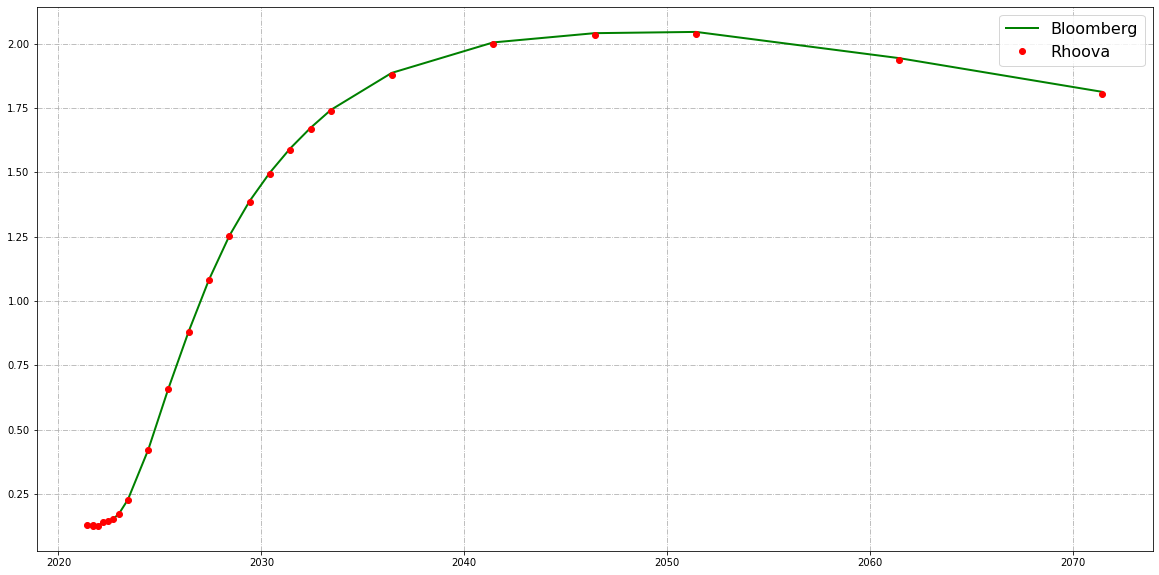

In [7]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvedicts.keys())
y1 =bloombergzerorates
y2 = list(rhoovayieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=4)
#
leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

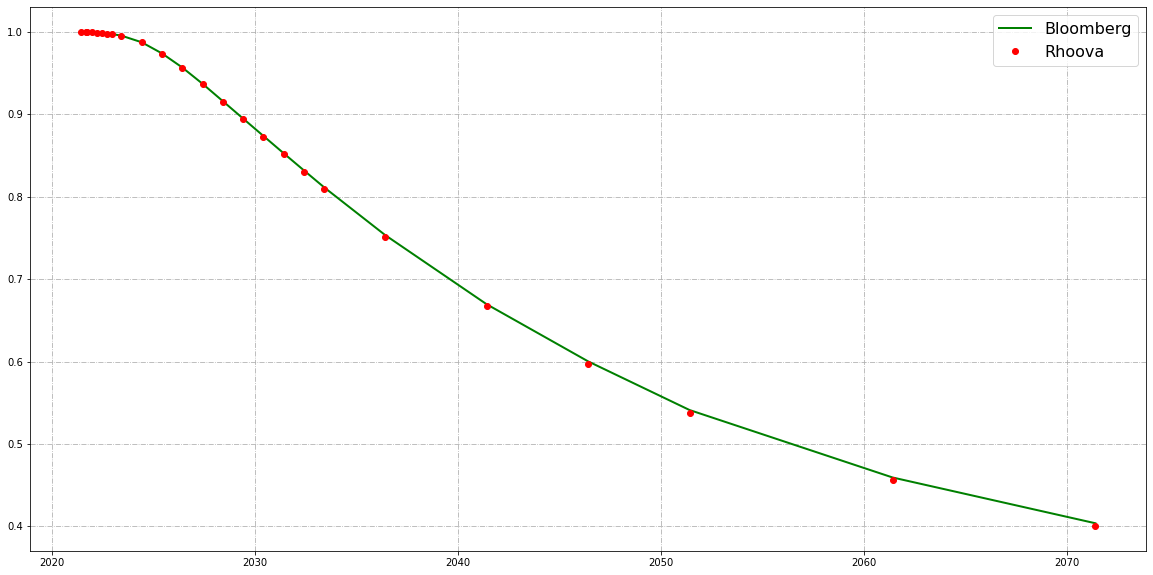

In [8]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvediscounts.keys())
y1 =bloombergdiscountrates
y2 = list(rhoovayieldcurvediscounts.values())

ax.plot(x,y1, 'g', label='Bloomberg', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=12)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

In [9]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','Bloomberg ZR','Rhoova Discount Rate','Bloomberg DR'])
i=0
for key, val in rhoovayieldcurvedicts.items():
    pTable.add_row([key, val,bloombergzerorates[i],rhoovayieldcurvediscounts.get(key),bloombergdiscountrates[i]])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+--------------+----------------------+--------------+
|  Maturity  | Rhoova ZeroRates | Bloomberg ZR | Rhoova Discount Rate | Bloomberg DR |
+------------+------------------+--------------+----------------------+--------------+
| 2021-06-04 |     0.128478     |   0.130260   |          1           |   1.000000   |
| 2021-09-07 |     0.128478     |   0.130260   |       0.999661       |   0.999661   |
| 2021-09-16 |     0.126489     |   0.129330   |       0.999635       |   0.999635   |
| 2021-12-15 |     0.124726     |   0.125430   |       0.999328       |   0.999334   |
| 2022-03-15 |     0.139854     |   0.139900   |       0.998897       |   0.998908   |
| 2022-06-16 |     0.144188     |   0.143390   |       0.998491       |   0.998524   |
| 2022-09-15 |     0.153638     |   0.153670   |       0.998005       |   0.998006   |
| 2022-12-21 |     0.172117     |   0.171130   |       0.997302       |   0.997354   |
| 2023-06-05 |     0.227535     |   0.22770

In [10]:
# Fix parameters for building yield curve

yieldcurveconfig['applyShock']={
  "method": "parallel",
  "shockValues" : [
    {
      "tenor" : "all",
      "shockValue" : 50.0
    }
  ]
}

In [11]:
result =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, result,True)
    result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

In [12]:
zerorates=result.get("zeroRates"),
discountrates=result.get("discountRates")
dates=[]
forwarddates= {}
rhoovapyieldcurvedicts = {}
rhoovapyieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovapyieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovapyieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

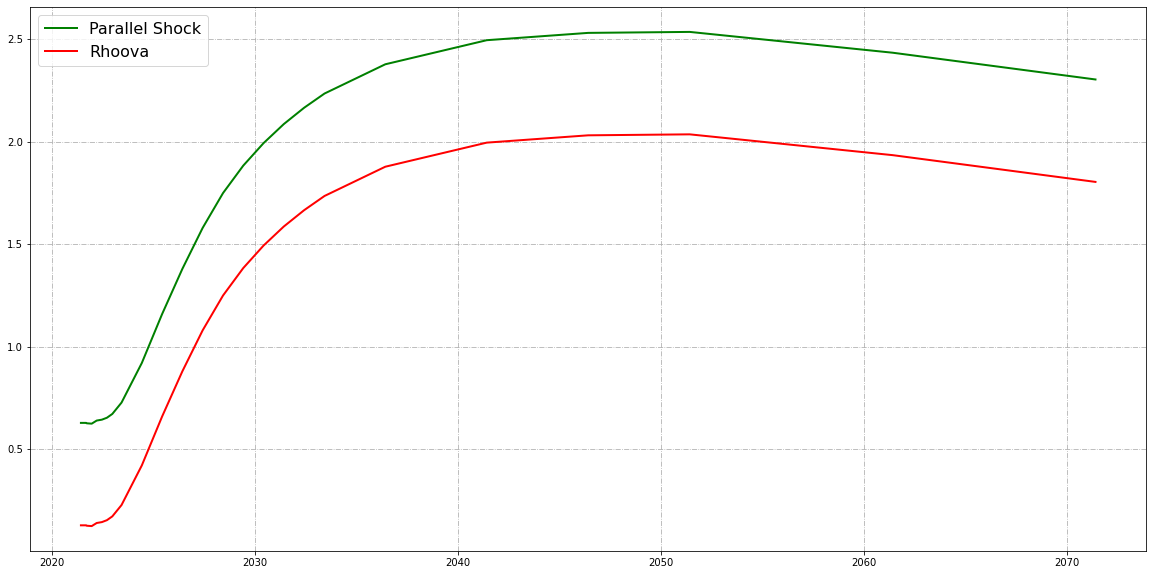

In [13]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvedicts.keys())
y1 =list(rhoovapyieldcurvedicts.values())
y2 = list(rhoovayieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Parallel Shock', linewidth=2)
ax.plot(x,y2, 'r', label='Rhoova', linewidth=2)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

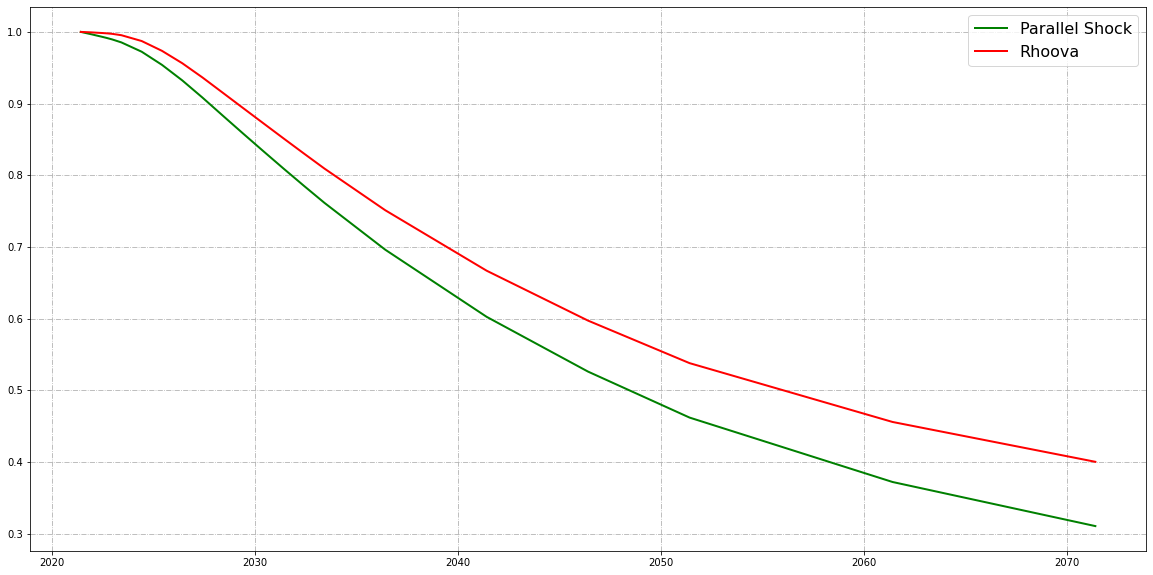

In [14]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvediscounts.keys())
y2 = list(rhoovapyieldcurvediscounts.values())
y3 = list(rhoovayieldcurvediscounts.values())


ax.plot(x,y2, 'g', label='Parallel Shock', linewidth=2)
ax.plot(x,y3, 'r', label='Rhoova', linewidth=2)


leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

In [15]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','ZeroRates with Shock','Rhoova Discount Rate','Discount Rate with Shock'])
i=0
for key, val in rhoovayieldcurvedicts.items():
    pTable.add_row([key, val,rhoovapyieldcurvedicts.get(key),rhoovayieldcurvediscounts.get(key),rhoovapyieldcurvediscounts.get(key)])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+----------------------+----------------------+--------------------------+
|  Maturity  | Rhoova ZeroRates | ZeroRates with Shock | Rhoova Discount Rate | Discount Rate with Shock |
+------------+------------------+----------------------+----------------------+--------------------------+
| 2021-06-04 |     0.128478     |       0.628478       |          1           |            1             |
| 2021-09-07 |     0.128478     |       0.628478       |       0.999661       |         0.998343         |
| 2021-09-16 |     0.126489     |       0.626489       |       0.999635       |         0.998192         |
| 2021-12-15 |     0.124726     |       0.624726       |       0.999328       |         0.996639         |
| 2022-03-15 |     0.139854     |       0.639854       |       0.998897       |         0.994965         |
| 2022-06-16 |     0.144188     |       0.644188       |       0.998491       |         0.993277         |
| 2022-09-15 |     0.153638     |    

In [16]:
yieldcurveconfig['applyShock']={
  "method": "nonparallel",
  "shockValues" : [
    {
      "tenor" : "2Y",
      "shockValue" : 20
    },
    {
      "tenor" : "5Y",
      "shockValue" : 50
    },
    {
      "tenor" : "12Y",
      "shockValue" : 25
    }
      ,
    {
      "tenor" : "50Y",
      "shockValue" : 0
    }
  ]
}


In [17]:
yieldcurve =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, yieldcurve,True)
    result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

In [18]:
zerorates=result.get("zeroRates"),
discountrates=result.get("discountRates")
dates=[]
forwarddates= {}
rhoovanpyieldcurvedicts = {}
rhoovanpyieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovanpyieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovanpyieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

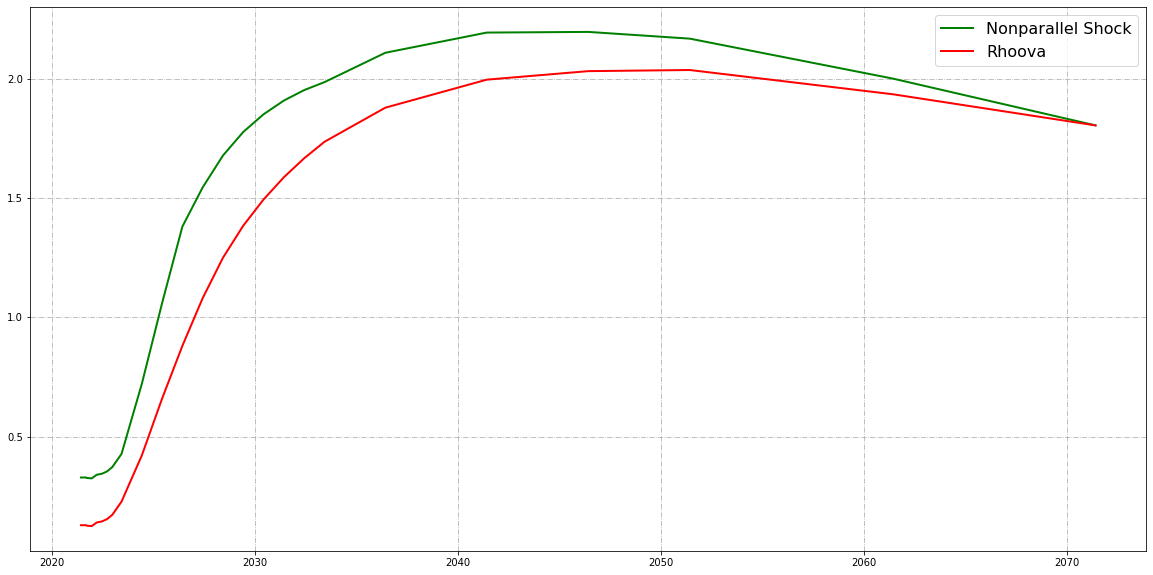

In [19]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvedicts.keys())
y1 =list(rhoovanpyieldcurvedicts.values())
y2 = list(rhoovayieldcurvedicts.values())


ax.plot(x,y1, 'g', label='Nonparallel Shock', linewidth=2)
ax.plot(x,y2, 'r', label='Rhoova', linewidth=2)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

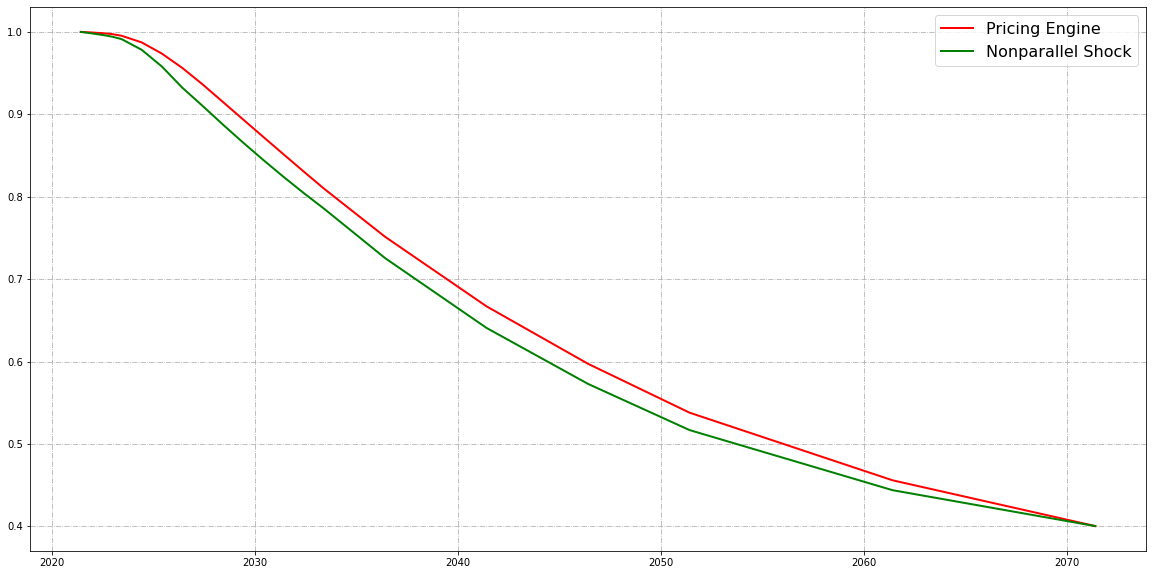

In [20]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvediscounts.keys())
y2 = list(rhoovayieldcurvediscounts.values())
y3 = list(rhoovanpyieldcurvediscounts.values())


ax.plot(x,y2, 'r', label='Pricing Engine', linewidth=2)
ax.plot(x,y3, 'g', label='Nonparallel Shock', linewidth=2)


leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

In [21]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','ZeroRates with Shock','Rhoova Discount Rate','Discount Rate with Shock'])
i=0
for key, val in rhoovayieldcurvedicts.items():
    pTable.add_row([key, val,rhoovanpyieldcurvedicts.get(key),rhoovayieldcurvediscounts.get(key),rhoovanpyieldcurvediscounts.get(key)])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+----------------------+----------------------+--------------------------+
|  Maturity  | Rhoova ZeroRates | ZeroRates with Shock | Rhoova Discount Rate | Discount Rate with Shock |
+------------+------------------+----------------------+----------------------+--------------------------+
| 2021-06-04 |     0.128478     |       0.328478       |          1           |            1             |
| 2021-09-07 |     0.128478     |       0.328478       |       0.999661       |         0.999134         |
| 2021-09-16 |     0.126489     |       0.326489       |       0.999635       |         0.999057         |
| 2021-12-15 |     0.124726     |       0.324726       |       0.999328       |         0.998252         |
| 2022-03-15 |     0.139854     |       0.339854       |       0.998897       |         0.997323         |
| 2022-06-16 |     0.144188     |       0.344188       |       0.998491       |         0.996402         |
| 2022-09-15 |     0.153638     |    

In [22]:
# Fix parameters for building yield curve

yieldcurveconfig['applyShock']={
  "method": "keyrate",
  "shockValues" : [
    {
      "tenor" : "259D",
      "shockValue" : 100.0
    },
    {
      "tenor" : "10Y",
      "shockValue" : 200.0
    }
  ]
}

In [23]:
result =  {
    "valuationDate": "2021-06-02",
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, result,True)
    result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

In [24]:
zerorates=result.get("zeroRates"),
discountrates=result.get("discountRates")
dates=[]
forwarddates= {}
rhoovanp2yieldcurvedicts = {}
rhoovanp2yieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovanp2yieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovanp2yieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

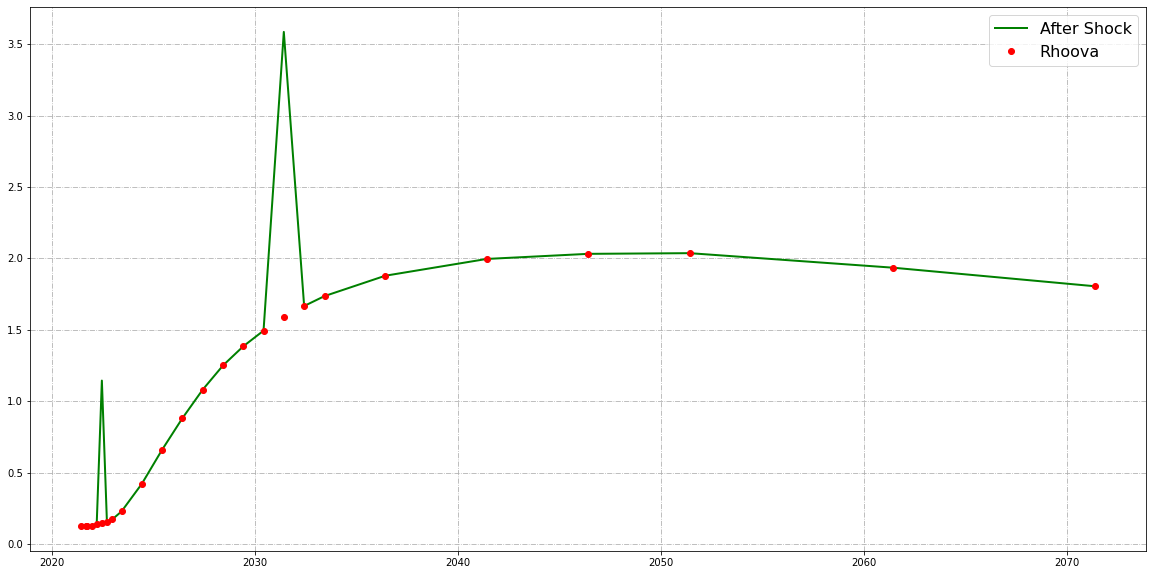

In [25]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvedicts.keys())
y1 =list(rhoovanp2yieldcurvedicts.values())
y2 = list(rhoovayieldcurvedicts.values())


ax.plot(x,y1, 'g', label='After Shock', linewidth=2)
ax.plot(x,y2, 'ro', label='Rhoova', linewidth=4)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

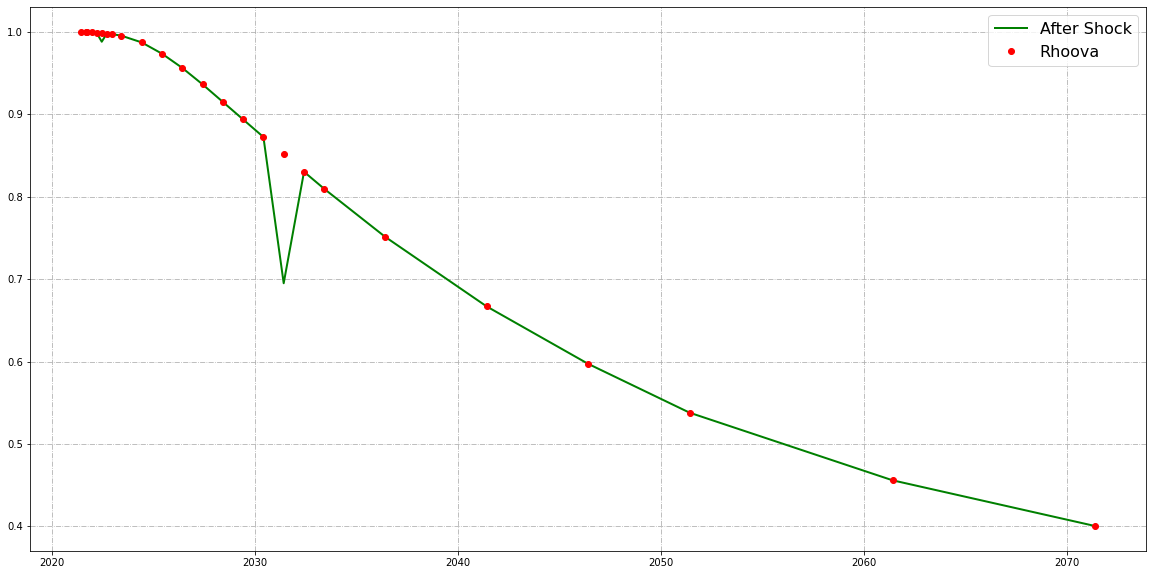

In [26]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovayieldcurvediscounts.keys())
y2 = list(rhoovanp2yieldcurvediscounts.values())
y3 = list(rhoovayieldcurvediscounts.values())


ax.plot(x,y2, 'g', label='After Shock', linewidth=2)
ax.plot(x,y3, 'ro', label='Rhoova', linewidth=2)


leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()

In [27]:
pTable = pt.PrettyTable(['Maturity','Rhoova ZeroRates','ZeroRates with Shock','Rhoova Discount Rate','Discount Rate with Shock'])
i=0
for key, val in rhoovayieldcurvedicts.items():
    pTable.add_row([key, val,rhoovanp2yieldcurvedicts.get(key),rhoovayieldcurvediscounts.get(key),rhoovanp2yieldcurvediscounts.get(key)])
    i=i+1
pTable.align = 'c'
pTable.float_format = '.6'
print(pTable)

+------------+------------------+----------------------+----------------------+--------------------------+
|  Maturity  | Rhoova ZeroRates | ZeroRates with Shock | Rhoova Discount Rate | Discount Rate with Shock |
+------------+------------------+----------------------+----------------------+--------------------------+
| 2021-06-04 |     0.128478     |       0.128478       |          1           |            1             |
| 2021-09-07 |     0.128478     |       0.128478       |       0.999661       |         0.999661         |
| 2021-09-16 |     0.126489     |       0.126489       |       0.999635       |         0.999635         |
| 2021-12-15 |     0.124726     |       0.124726       |       0.999328       |         0.999328         |
| 2022-03-15 |     0.139854     |       0.139854       |       0.998897       |         0.998897         |
| 2022-06-16 |     0.144188     |       1.144188       |       0.998491       |         0.988089         |
| 2022-09-15 |     0.153638     |    

In [28]:
# Fix parameters for building yield curve
yieldcurveconfig['applyShock']={
  "method": "keyrate",
  "shockValues" : [
    {
      "tenor" : "2Y",
      "shockValue" : 100.0
    }
  ]
}

In [29]:
from datetime import datetime

zerodates=list(pd.date_range(start="2021-06-04",end="2071-06-04 "))
zeros=[]
for i in zerodates:
    zeros.append(i.strftime("%Y-%m-%d"))

In [ ]:
result =  {
    "valuationDate": "2021-06-02",
    "zeroRates": {
        "analysisDates": zeros,
        "compounding": "Continuous",
        "frequency": "Annual"
    },
    "endOfMonth": True,
    "yieldCurve":yieldcurveconfig ,
    "yieldData": yielddata.to_dict('r')
}
try:
    result = api.createTask(CalculationType.YIELD_CURVE, result,True)
    result=json.loads(result["result"])
except RhoovaError as e:
    e.printPretty()

In [ ]:
zerorates=result.get("zeroRates"),
discountrates=result.get("discountRates")
dates=[]
forwarddates= {}
rhoovanp2yieldcurvedicts = {}
rhoovanp2yieldcurvediscounts = {}
for rhvzr in zerorates[0]:
    rhoovanp2yieldcurvedicts[datetime.strptime(rhvzr.get('date'),'%Y-%m-%d').date()] = rhvzr.get('rate')*100
    dates.append(rhvzr.get('date'))

for rhv in discountrates:
    rhoovanp2yieldcurvediscounts[datetime.strptime(rhv.get('date'), '%Y-%m-%d').date()] = rhv.get('rate')
    

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))

x=list(rhoovanp2yieldcurvedicts.keys())
y1 =list(rhoovanp2yieldcurvedicts.values())


ax.plot(x,y1, 'g', label='After Shock', linewidth=2)

leg = ax.legend(prop={'size': 16});
plt.grid(linestyle='dashdot')
plt.show()